In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv("train.csv",header = None)
df

,0,1,2,3,4,5,6,7,8,9,...,112,113,114,115,116,117,118,119,120,121
0,69769,-946,0.1613,0.7960,Panl,N,Bus2,0.0742,0,2,...,1.0,-4670.0,0.9851,0.0000,0.0,Mard,0.0,0.3333,0.0,0.0
1,236977,-92,NaN,NaN,NaN,Y,Othr,NaN,0,3,...,NaN,-1994.0,NaN,NaN,0.0,Mard,0.0,NaN,0.0,0.0
2,168821,-1646,0.1124,0.8504,Panl,N,Bus3,0.0387,0,2,...,2.0,-2842.0,0.9891,0.0000,0.0,Sind,0.0,0.3750,0.0,1.0
3,94708,-1651,0.0263,NaN,Blok,N,Bus3,NaN,0,2,...,4.0,-1345.0,0.9682,0.0000,0.0,Sind,0.0,0.0417,0.0,1.0
4,84556,-977,NaN,NaN,NaN,N,Rest,NaN,0,2,...,NaN,-852.0,NaN,NaN,0.0,Sind,0.0,NaN,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105055,233184,-909,0.1757,0.8912,Panl,N,Bus3,0.1150,0,2,...,0.0,-135.0,0.9871,0.0344,0.0,Mard,2.0,0.3333,1.0,0.0
105056,96972,-800,NaN,NaN,NaN,N,Govt,NaN,0,3,...,0.0,-3148.0,NaN,NaN,0.0,Sind,0.0,NaN,1.0,0.0
105057,198531,-1559,NaN,NaN,NaN,N,Bus3,NaN,0,2,...,0.0,-2556.0,0.9816,NaN,0.0,Sind,0.0,NaN,0.0,0.0
105058,243456,-1404,NaN,NaN,NaN,N,Bus3,NaN,0,2,...,6.0,-4152.0,NaN,NaN,0.0,Sind,0.0,NaN,0.0,0.0


In [ ]:
np.info(df)

Two-dimensional, size-mutable, potentially heterogeneous tabular data.

Data structure also contains labeled axes (rows and columns).
Arithmetic operations align on both row and column labels. Can be
thought of as a dict-like container for Series objects. The primary
pandas data structure.

Parameters
----------
data : ndarray (structured or homogeneous), Iterable, dict, or DataFrame
    Dict can contain Series, arrays, constants, dataclass or list-like objects. If
    data is a dict, column order follows insertion-order. If a dict contains Series
    which have an index defined, it is aligned by its index.

    .. versionchanged:: 0.25.0
       If data is a list of dicts, column order follows insertion-order.

index : Index or array-like
    Index to use for resulting frame. Will default to RangeIndex if
    no indexing information part of input data and no index provided.
columns : Index or array-like
    Column labels to use for resulting frame when data does not have them,
    defa

In [ ]:
df.dtypes

69769                   int64
-946                    int64
0.1613                float64
0.7959999999999999    float64
Panl                   object
                       ...   
Mard                   object
0.0.14                float64
0.3333.2              float64
0.27                    int64
0.28                    int64
Length: 122, dtype: object

In [ ]:
null_count = df[:].isnull().sum()

print(null_count)

0          0
1          0
2      61385
3      69780
4      53327
       ...  
117        1
118      349
119    52214
120        1
121        1
Length: 122, dtype: int64


In [ ]:

missing_percentage = null_count / len(df.columns)

# select the columns where the percent of missing values is greater than 30%
missing_cols_lower_30 = missing_percentage[missing_percentage < 0.3].index.tolist()
print(missing_cols_lower_30)

[0, 1, 5, 6, 8, 9, 15, 19, 20, 23, 24, 26, 28, 29, 30, 31, 33, 37, 40, 41, 42, 46, 47, 50, 52, 53, 55, 57, 62, 63, 64, 65, 66, 67, 69, 70, 71, 73, 75, 76, 81, 85, 93, 94, 97, 98, 99, 100, 103, 104, 105, 106, 108, 113, 116, 117, 120, 121]


In [ ]:
len(df.columns)

122

In [ ]:
len(missing_cols_lower_30)

58

In [ ]:
missing_cols_lower_20 = missing_percentage[missing_percentage < 0.2].index.tolist()
print(missing_cols_lower_20)

[0, 1, 5, 6, 8, 9, 15, 19, 20, 23, 24, 26, 28, 29, 30, 31, 33, 37, 40, 41, 42, 46, 47, 50, 52, 53, 55, 57, 62, 63, 64, 65, 66, 67, 69, 70, 71, 73, 75, 76, 81, 85, 93, 94, 97, 98, 99, 100, 103, 104, 105, 106, 108, 113, 116, 117, 120, 121]


In [ ]:
len(missing_cols_lower_20)

58

In [ ]:
missing_cols_lower_20 == missing_cols_lower_30

True

So, there is no data between missing part of columns %20-%30

In [ ]:
missing_cols_lower_10 = missing_percentage[missing_percentage < 0.1].index.tolist()
print(missing_cols_lower_10)

[0, 1, 5, 6, 8, 9, 15, 19, 20, 23, 24, 26, 28, 29, 30, 31, 33, 37, 40, 41, 42, 46, 47, 50, 52, 53, 55, 57, 62, 63, 64, 65, 66, 67, 69, 70, 71, 73, 75, 76, 81, 85, 93, 94, 97, 98, 99, 100, 103, 104, 105, 106, 108, 113, 116, 117, 120, 121]


In [ ]:
len(missing_cols_lower_10)

58

In [ ]:
missing_cols_lower_10 == missing_cols_lower_30

True

So, there is no data between missing part of columns %10-%30

In [ ]:
missing_cols_higher_30 = missing_percentage[missing_percentage > 0.3].index.tolist()
print(missing_cols_higher_30)

[2, 3, 4, 7, 10, 11, 12, 13, 14, 16, 17, 18, 21, 22, 25, 27, 32, 34, 35, 36, 38, 39, 43, 44, 45, 48, 49, 51, 54, 56, 58, 59, 60, 61, 68, 72, 74, 77, 78, 79, 80, 82, 83, 84, 86, 87, 88, 89, 90, 91, 92, 95, 96, 101, 102, 107, 109, 110, 111, 112, 114, 115, 118, 119]


In [ ]:
len(missing_cols_higher_30)

64

In [ ]:
df.shape[1]

122

There are a total of 122 columns in this data. Of these, 64 are missing more than 30% of the data. 58 are missing less than 20% of the data.

In [ ]:
import missingno as msno

<Axes: >

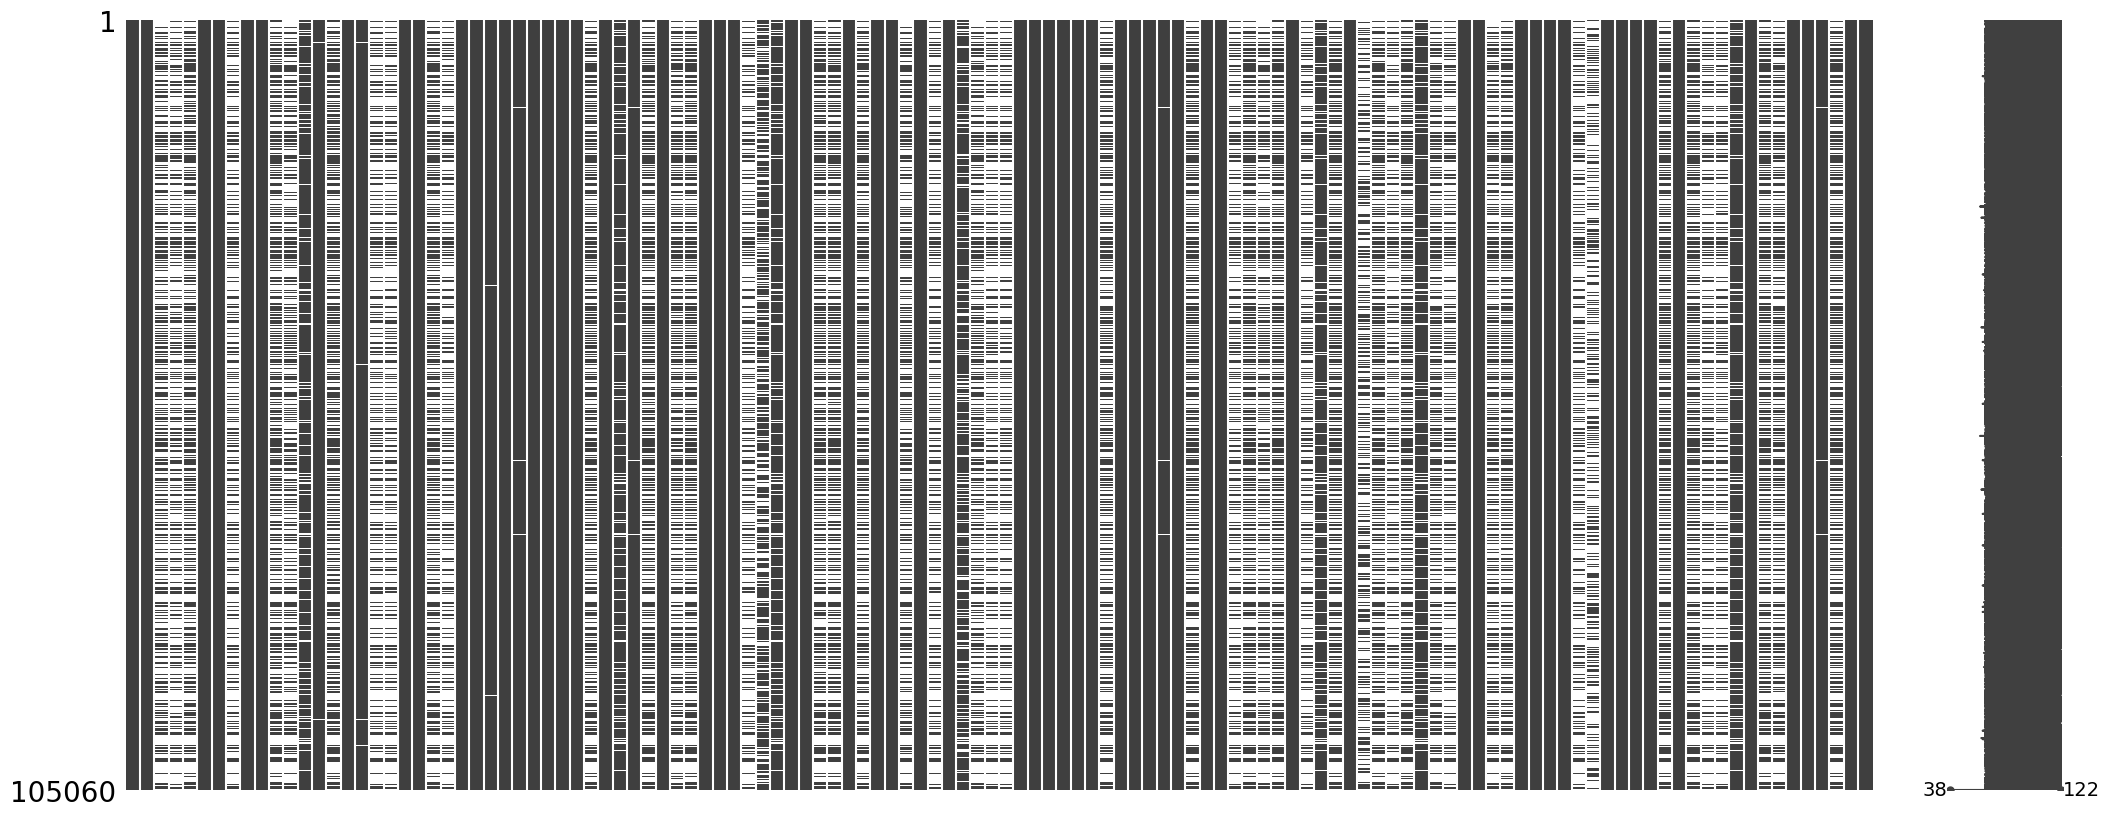

In [ ]:
# create a matrix visualization of missing data for the entire dataframe
msno.matrix(df)

The cells in the matrix are colored based on the amount of missing data in each column. The darker the cell, the more missing data it contains.

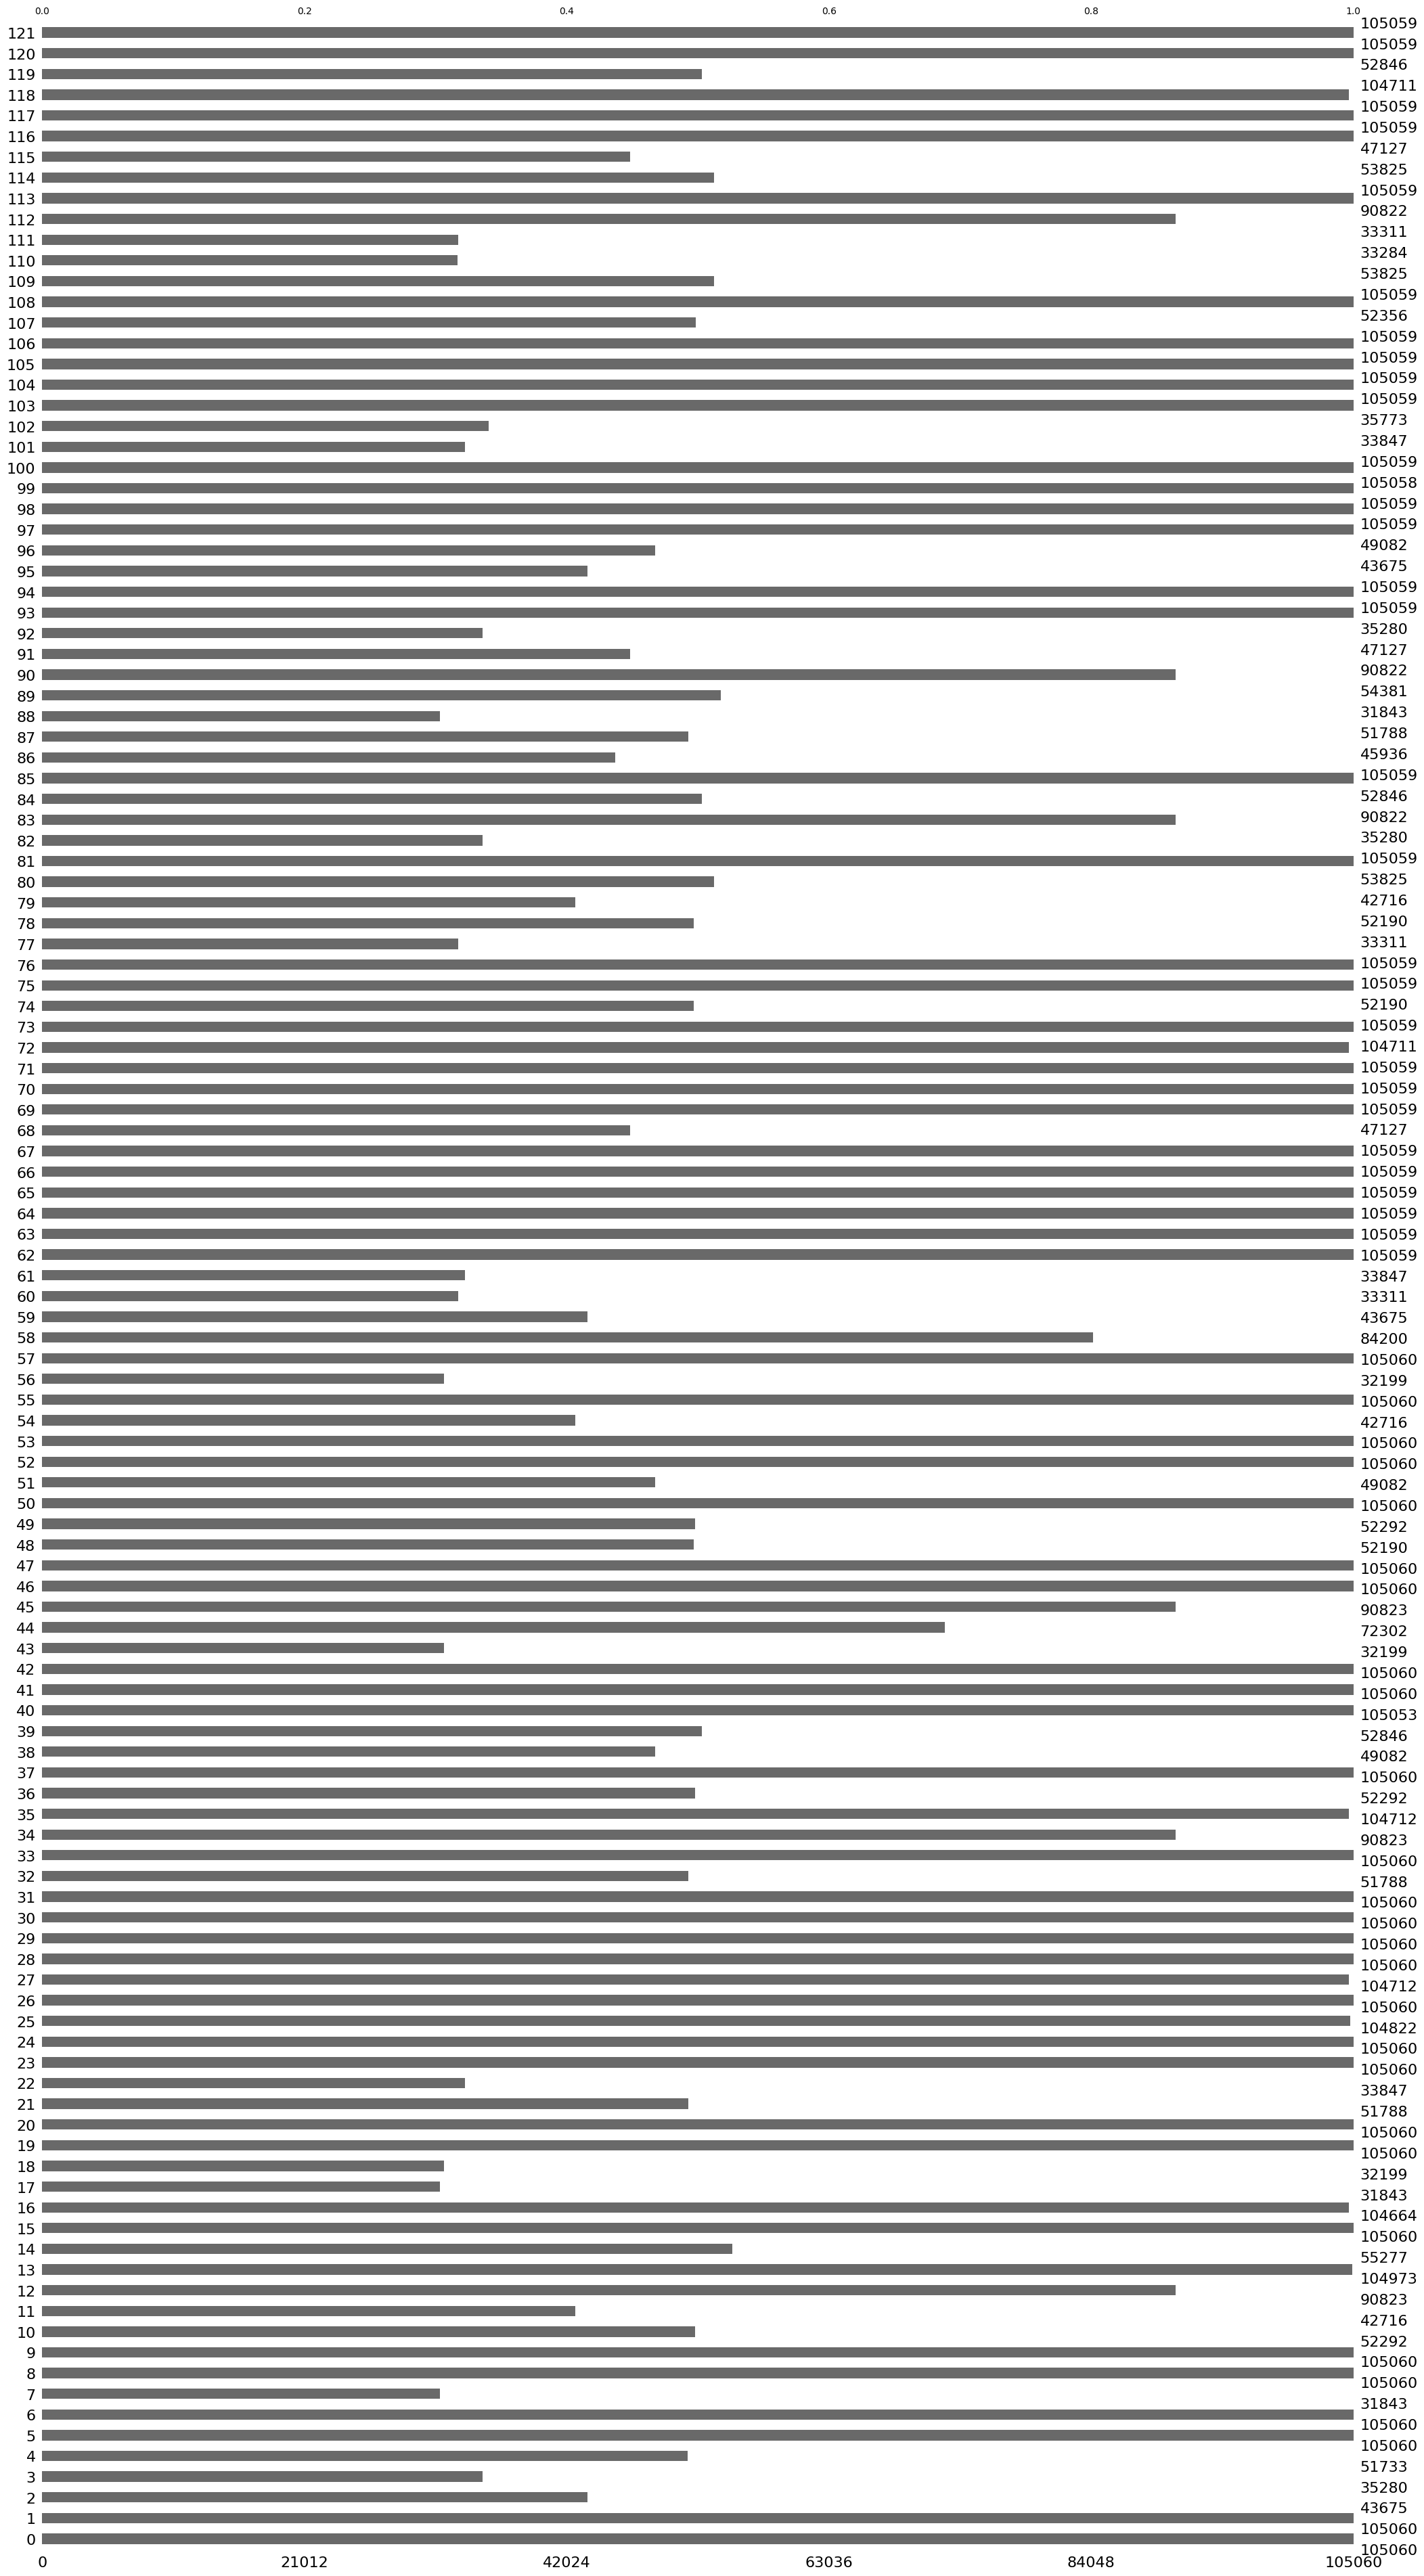

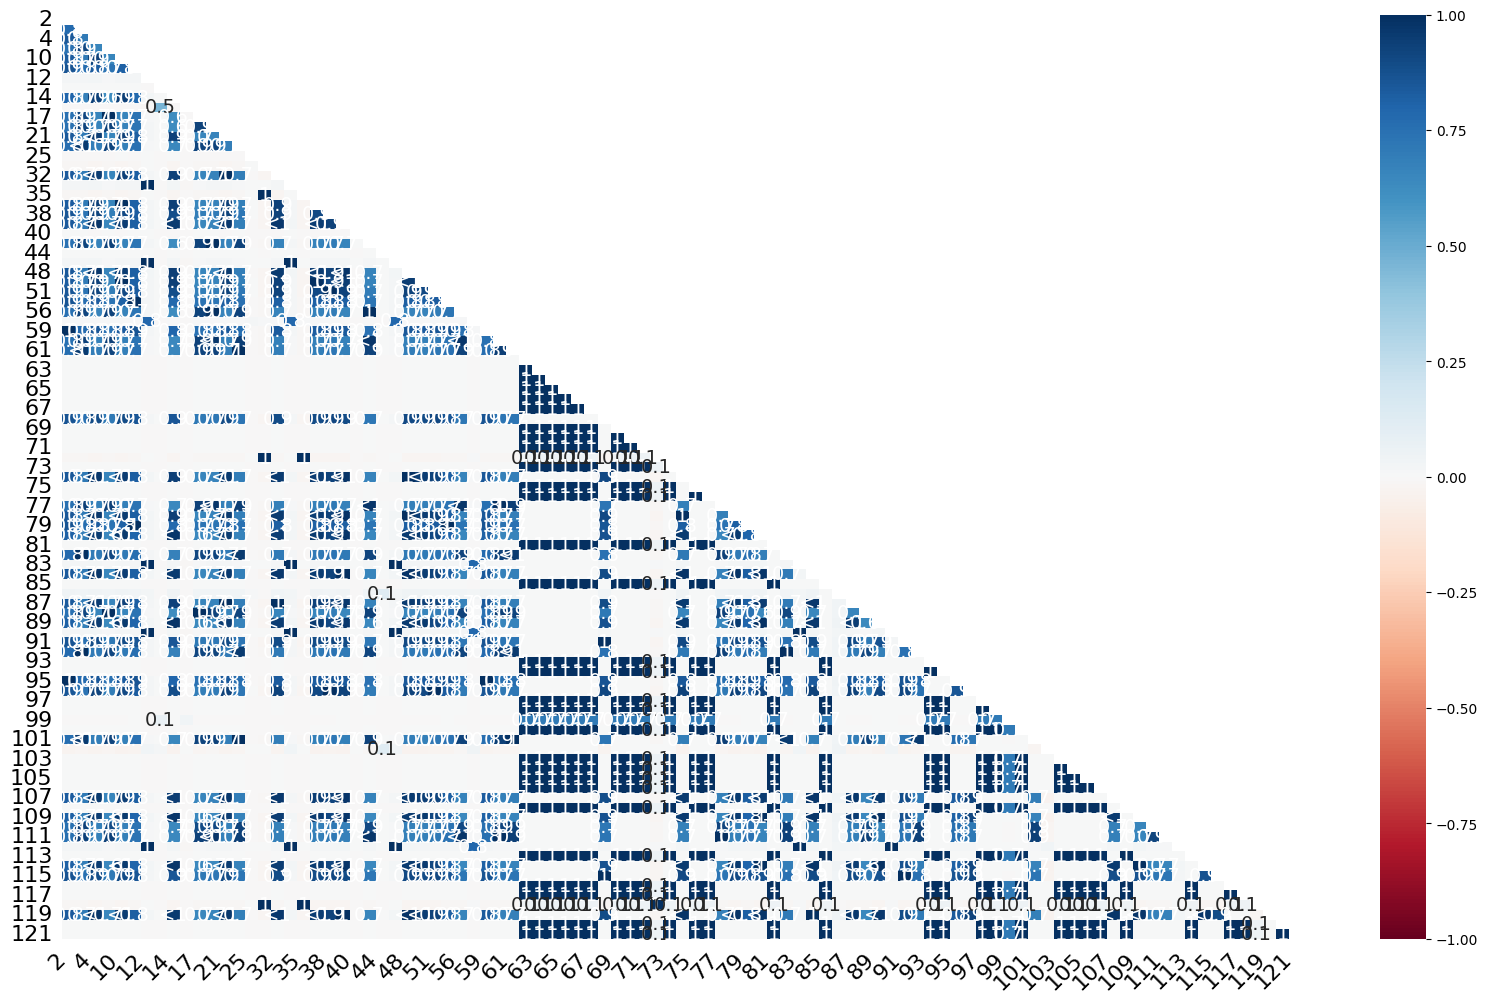

In [ ]:
import matplotlib.pyplot as plt

# creating a bar plot of the missing data
msno.bar(df)
plt.show()

# create a heatmap plot of the missing data
msno.heatmap(df)
plt.show()

<Axes: >

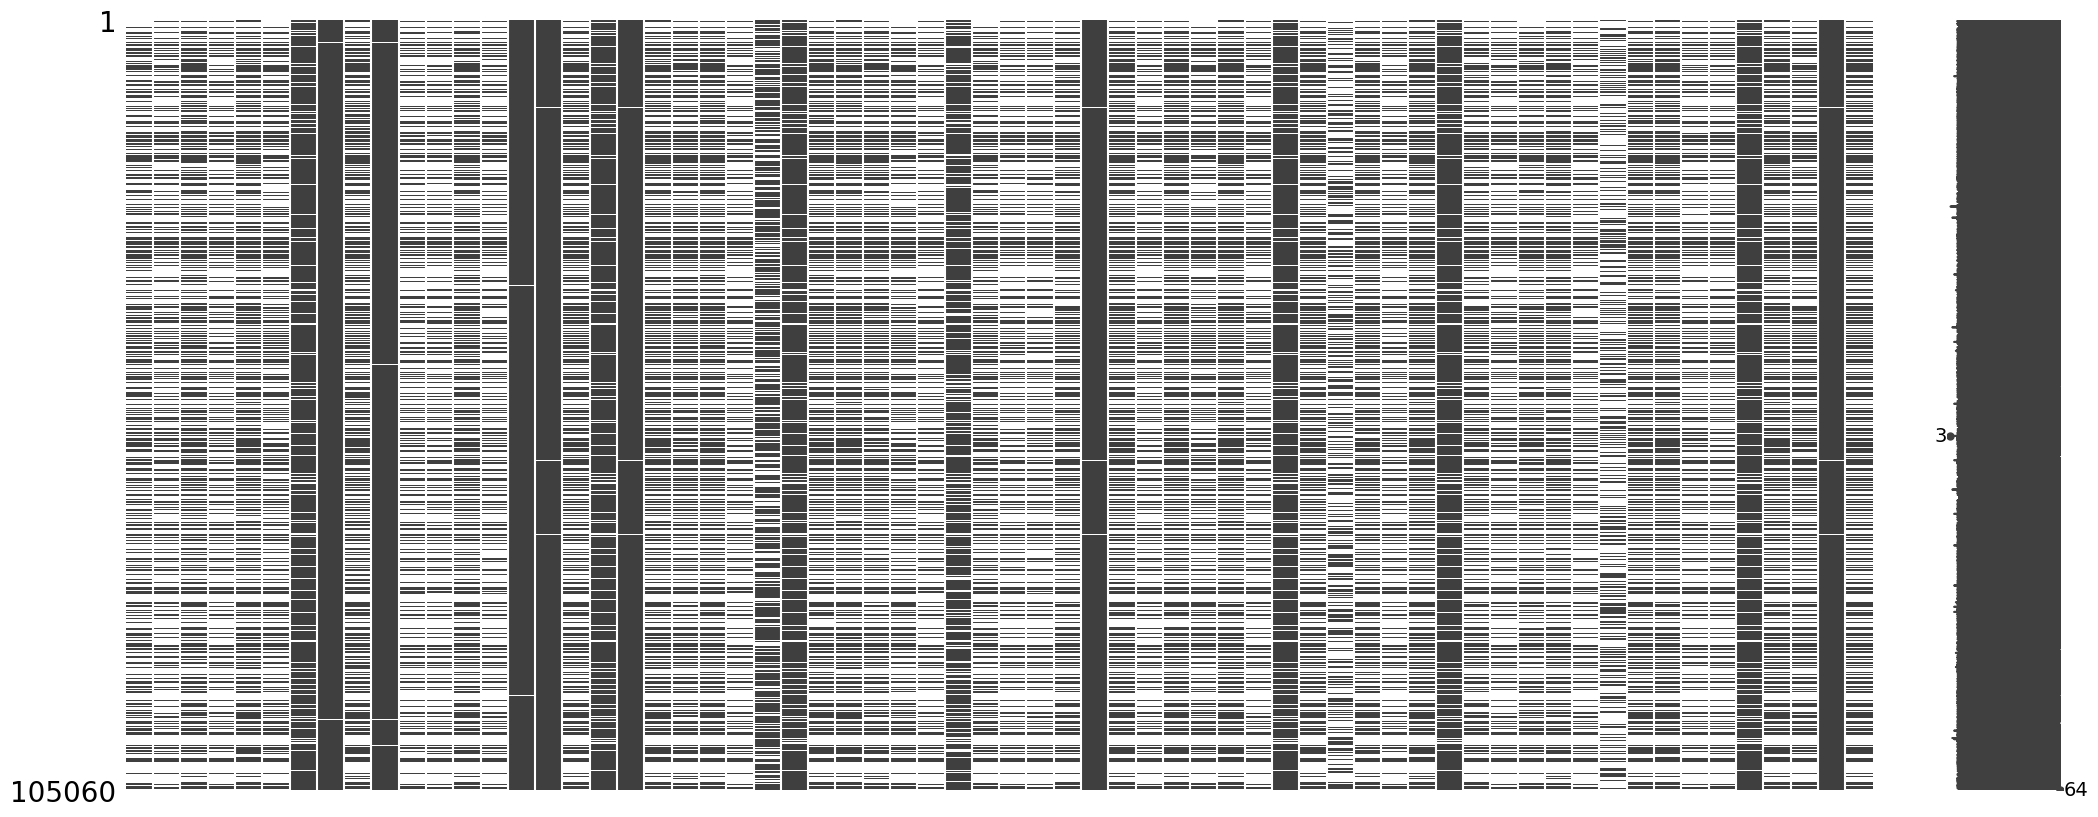

In [ ]:
# creating a new dataframe that contains only the selected columns with missing values
# using the missingno library to create a visualization of the missing data
msno.matrix(df[missing_cols_higher_30])

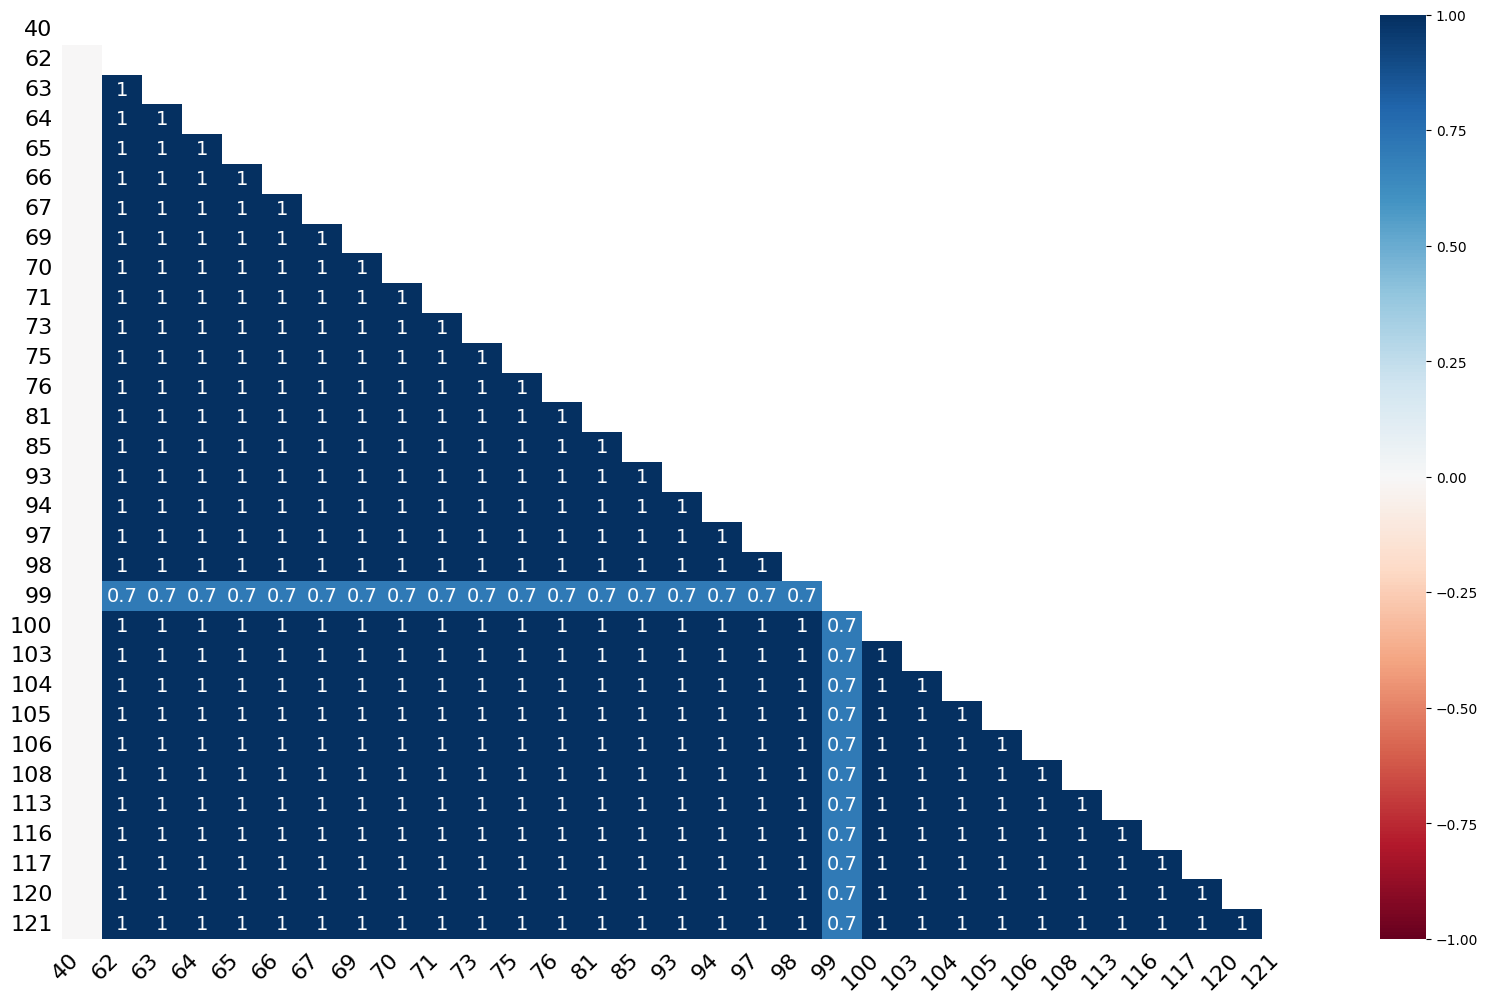

In [ ]:
# create a heatmap plot of the missing data
msno.heatmap(missing_cols_lower_10)
plt.show()

In [ ]:
# Check for duplicate rows
duplicate_rows = df[df.duplicated()]

# Print the number of duplicate rows
print("Number of duplicate rows: ", len(duplicate_rows))

# Print the duplicate rows
print(duplicate_rows)


Number of duplicate rows:  0
Empty DataFrame
Columns: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]
Index: []

[0 rows x 122 columns]


No exactly the same column or row

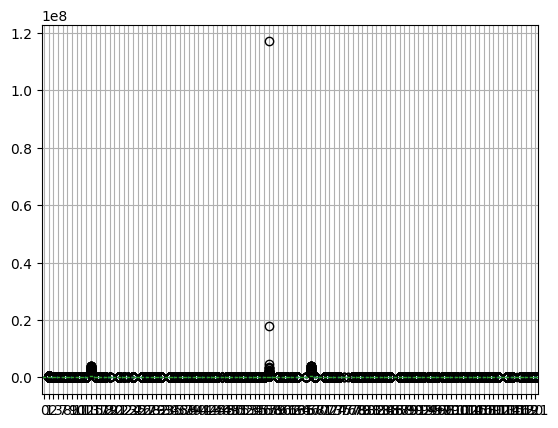

In [ ]:
df.boxplot()
plt.show()

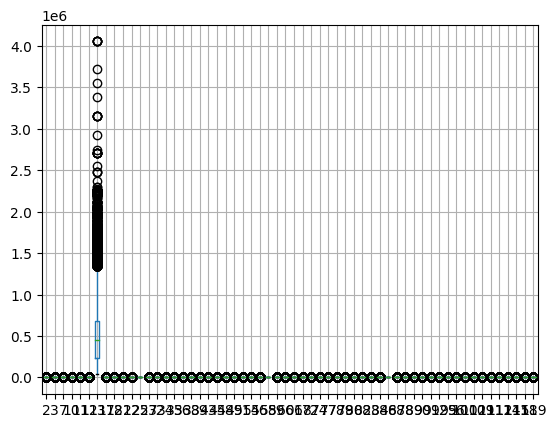

In [ ]:
df[missing_cols_higher_30].boxplot()
plt.show()

In [ ]:
filled_missing_cols_higher_30 = df.columns[df.isna().mean() > 0.3]
df_filled_mean = df.copy()
df_filled_mean[filled_missing_cols_higher_30] = df[filled_missing_cols_higher_30].fillna(df[filled_missing_cols_higher_30].mean(skipna=True))


<ipython-input-91-19f693b7dfd6>:3: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  df_filled_mean[filled_missing_cols_higher_30] = df[filled_missing_cols_higher_30].fillna(df[filled_missing_cols_higher_30].mean(skipna=True))


In [ ]:
len(filled_missing_cols_higher_30)

50

In [ ]:
df_filled_mean = df
df.fillna(df[missing_cols_higher_30].mean())

<ipython-input-90-75dbd0b73299>:2: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  df.fillna(df[missing_cols_higher_30].mean())


,0,1,2,3,4,5,6,7,8,9,...,112,113,114,115,116,117,118,119,120,121
0,69769,-946,0.161300,0.796000,Panl,N,Bus2,0.074200,0,2,...,1.000000,-4670.0,0.985100,0.000000,0.0,Mard,0.000000,0.333300,0.0,0.0
1,236977,-92,0.088363,0.752004,NaN,Y,Othr,0.042357,0,3,...,1.909857,-1994.0,0.976978,0.027235,0.0,Mard,0.000000,0.225601,0.0,0.0
2,168821,-1646,0.112400,0.850400,Panl,N,Bus3,0.038700,0,2,...,2.000000,-2842.0,0.989100,0.000000,0.0,Sind,0.000000,0.375000,0.0,1.0
3,94708,-1651,0.026300,0.752004,Blok,N,Bus3,0.042357,0,2,...,4.000000,-1345.0,0.968200,0.000000,0.0,Sind,0.000000,0.041700,0.0,1.0
4,84556,-977,0.088363,0.752004,NaN,N,Rest,0.042357,0,2,...,1.909857,-852.0,0.976978,0.027235,0.0,Sind,0.000000,0.225601,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105055,233184,-909,0.175700,0.891200,Panl,N,Bus3,0.115000,0,2,...,0.000000,-135.0,0.987100,0.034400,0.0,Mard,2.000000,0.333300,1.0,0.0
105056,96972,-800,0.088363,0.752004,NaN,N,Govt,0.042357,0,3,...,0.000000,-3148.0,0.976978,0.027235,0.0,Sind,0.000000,0.225601,1.0,0.0
105057,198531,-1559,0.088363,0.752004,NaN,N,Bus3,0.042357,0,2,...,0.000000,-2556.0,0.981600,0.027235,0.0,Sind,0.000000,0.225601,0.0,0.0
105058,243456,-1404,0.088363,0.752004,NaN,N,Bus3,0.042357,0,2,...,6.000000,-4152.0,0.976978,0.027235,0.0,Sind,0.000000,0.225601,0.0,0.0


In [ ]:
df_filled_mean.shape[1]

122

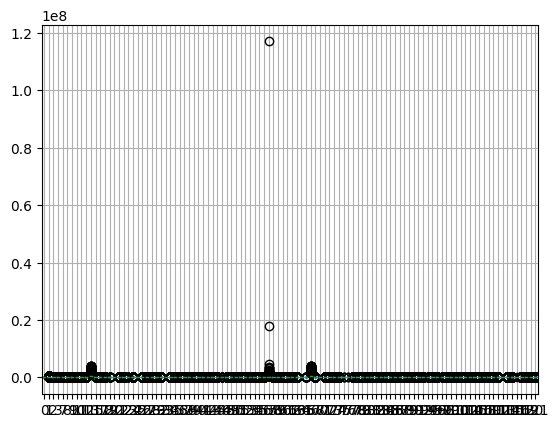

In [ ]:
df_filled_mean.boxplot()
plt.show()